In [20]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [21]:
class BMIstate(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [22]:
def cal_bmi (state:BMIstate)->BMIstate:
    weight=state ["weight_kg"]
    height= state['height_m']
    bmi=weight/(height**2)

    state['bmi']=round(bmi,2)

    return state

In [23]:
def label_bmi(state: BMIstate) -> BMIstate:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state


In [26]:
graph=StateGraph(BMIstate)

graph.add_node('cal_bmi',cal_bmi)

graph.add_node('label_bmi',label_bmi)

graph.add_edge(START,'cal_bmi')
graph.add_edge('cal_bmi','label_bmi')
graph.add_edge('label_bmi',END)

workflow = graph.compile()


In [28]:
intial_state={'weight_kg':80,'height_m':1.73}

final_state=workflow.invoke(intial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


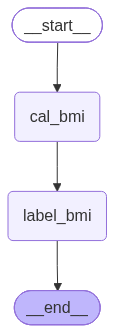

In [29]:

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())